# Job Retry & Lifecycle Sequence Analysis
### Where jobs actually have more than one row

We check that assumption against the data, quantify how often it's wrong, and turn "wrongness" into an operational signal: wasted core-hours, retry-prone users/campaigns, and which hold reasons actually predict a retry.


## Why this direction

**What the existing notebooks already cover:**
- `baseline-prediction.ipynb` — XGBoost / CatBoost / LightGBM binary failure classifiers, SHAP + gain-based feature importance, ROC/PR curves.
- `fnal-jobs.ipynb` — feature engineering (cyclical time encodings, categorical encoding, log/z-score transforms, regex-based hold-reason tagging) feeding a multimodal (tabular + DistilBERT text) failure-prediction network.
- `data-modeling.ipynb` — EDA on what "failure" even means for this dataset (the many ExitCode/ExitSignal/JobStatus edge cases), resource-efficiency and backfill-scheduling analysis, and an unfinished PCA/clustering pass at the end.

All three treat the row as the unit of analysis and predict outcomes for that row in isolation. None of them ask whether a "job" (as HTCondor/JobSub/POMS understands it) can appear more than once in the log — which is exactly the question the resubmission note raises.

**Current research framing.** Grid/HPC scheduling research on backfilling and job resubmission (going back to Feitelson & Mu'alem's work on parallel workload characterization, and continuing in HTCondor/glideinWMS operational literature) treats a *retry* as a distinct event from a *failure*: a job that fails and is never resubmitted is a dead end, but a job that fails and succeeds on retry is a scheduling/resource-provisioning cost, not necessarily a science problem. Standard supervised failure classifiers (like the ones already built here) can't see this distinction because they score one row at a time. Reconstructing retry pairs first is a prerequisite for that kind of analysis, and it's also standard practice in workflow-management-system research (DAGMan/Pegasus/POMS failure-recovery studies) before any per-job model is trained.

**What we do here:**
1. Check whether `(ClusterId, ProcId)` is really a unique job key in this dataset (it isn't).
2. Separate genuine multi-event jobs from plain ETL duplication.
3. Reconstruct first → final attempt sequences and see whether retries actually fix anything.
4. Price the problem in core-hours.
5. Find which hold reasons and which users/campaigns carry the retry burden.
6. Propose how this feeds back into the existing failure-prediction pipeline.


In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

pl.Config.set_tbl_rows(20)

path = "../data/processed_job_data_01.parquet"

cols = [
    "GlobalJobId", "ClusterId", "ProcId", "JobStatus", "LastJobStatus",
    "EnteredCurrentStatus_ms", "QDate_ms", "ExitCode", "ExitSignal",
    "LastHoldReason", "LastHoldReasonCode", "RemoveReason",
    "DAGManJobId", "POMS4_CAMPAIGN_STAGE_NAME", "POMS4_CAMPAIGN_NAME", "Group", "User",
    "RemoteWallClockTime", "CoreHours", "RequestCpus", "RequestMemory",
    "JOB_EXPECTED_MAX_LIFETIME", "MATCH_EXP_JOB_Site",
]

job_data = pl.scan_parquet(path).select(cols).collect()
print(f"Loaded {job_data.shape[0]:,} rows x {job_data.shape[1]} columns")


Loaded 8,629,248 rows x 23 columns


## 1. Data quality: exact duplicate rows

Before looking for *genuine* multi-event jobs, we need to rule out plain ETL duplication — the same log line ingested twice. We check for rows that are identical across every selected column (same `GlobalJobId` and everything else).


In [4]:
n_before = job_data.height
job_data = job_data.unique()
n_after = job_data.height
n_dupe_rows = n_before - n_after

print(f"Rows before dedup: {n_before:,}")
print(f"Rows after dedup:  {n_after:,}")
print(f"Exact-duplicate rows removed: {n_dupe_rows:,} ({n_dupe_rows / n_before:.3%} of the file)")


Rows before dedup: 8,629,248
Rows after dedup:  8,629,248
Exact-duplicate rows removed: 0 (0.000% of the file)


Small (~0.16%) but non-zero — a genuine ingestion artifact worth flagging to whoever owns the ETL pipeline, separate from anything below. Everything from here on uses the deduplicated frame.


## 2. Is `(ClusterId, ProcId)` actually a unique job key?

Every prior notebook uses `ClusterId`/`ProcId` as if one pair identifies exactly one job record. We check directly.


In [5]:
job_data = job_data.with_columns(
    pl.len().over(["ClusterId", "ProcId"]).alias("n_events")
)

n_unique_jobs = job_data.select(["ClusterId", "ProcId"]).n_unique()
multi_mask = pl.col("n_events") > 1
n_multi_jobs = job_data.filter(multi_mask).select(["ClusterId", "ProcId"]).n_unique()
n_multi_rows = job_data.filter(multi_mask).height

print(f"Unique (ClusterId, ProcId) jobs: {n_unique_jobs:,}")
print(f"Jobs with more than one row:     {n_multi_jobs:,}  ({n_multi_jobs / n_unique_jobs:.2%} of jobs)")
print(f"Rows those jobs account for:     {n_multi_rows:,}  ({n_multi_rows / job_data.height:.2%} of all rows)")

event_dist = (
    job_data.select(["ClusterId", "ProcId", "n_events"]).unique()
    ["n_events"].value_counts().sort("n_events")
)
print(event_dist)


Unique (ClusterId, ProcId) jobs: 7,873,545
Jobs with more than one row:     746,089  (9.48% of jobs)
Rows those jobs account for:     1,501,792  (17.40% of all rows)
shape: (7, 2)
┌──────────┬─────────┐
│ n_events ┆ count   │
│ ---      ┆ ---     │
│ u32      ┆ u32     │
╞══════════╪═════════╡
│ 1        ┆ 7127456 │
│ 2        ┆ 743527  │
│ 3        ┆ 63      │
│ 5        ┆ 832     │
│ 6        ┆ 1281    │
│ 7        ┆ 385     │
│ 8        ┆ 1       │
└──────────┴─────────┘


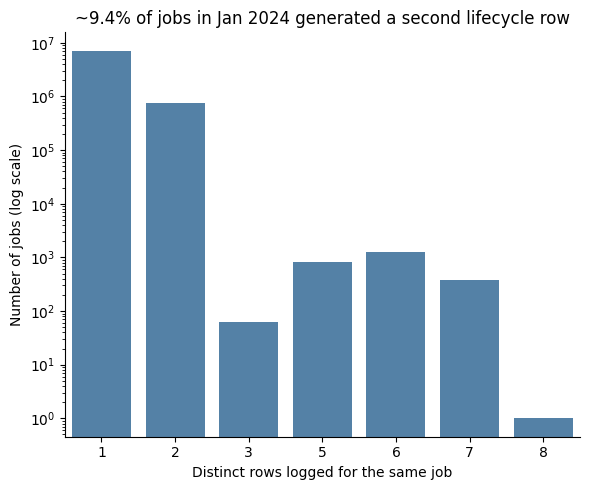

In [6]:
plot_df = event_dist.to_pandas()
plot_df["n_events"] = plot_df["n_events"].astype(str)

plt.figure(figsize=(6, 5))
sns.barplot(data=plot_df, x="n_events", y="count", color="steelblue")
plt.yscale("log")
plt.xlabel("Distinct rows logged for the same job")
plt.ylabel("Number of jobs (log scale)")
plt.title("~9.4% of jobs in Jan 2024 generated a second lifecycle row")
sns.despine()
plt.tight_layout()
plt.show()


No job in this month produced more than two genuine rows — so "sequence modeling" here reduces to a much simpler and more tractable question than the notes worried about: **first attempt vs. final attempt**, not arbitrary-length sequences. That's a meaningfully smaller problem than option 1 in the resubmission note (treating retries as variable-length sequences) — it means option 3 (a resubmission flag joined back to the parent job) is enough for this month's data, at least until later months are checked.


## 3. Are these workflow retries, or standalone resubmissions?

`DAGManJobId` is only populated for jobs that are nodes in a DAGMan workflow (typically POMS-managed production campaigns). If multi-event jobs are disproportionately DAG-linked, that tells us the retries are largely automated workflow recovery, not individual users resubmitting by hand.


In [7]:
dag_rate = (
    job_data
    .with_columns((pl.col("n_events") > 1).alias("is_multi_event"))
    .group_by("is_multi_event")
    .agg(
        pl.col("DAGManJobId").is_not_null().mean().alias("dag_linked_rate"),
        pl.len().alias("n_jobs_or_rows"),
    )
    .sort("is_multi_event")
)
print(dag_rate)


shape: (2, 3)
┌────────────────┬─────────────────┬────────────────┐
│ is_multi_event ┆ dag_linked_rate ┆ n_jobs_or_rows │
│ ---            ┆ ---             ┆ ---            │
│ bool           ┆ f64             ┆ u32            │
╞════════════════╪═════════════════╪════════════════╡
│ false          ┆ 0.364024        ┆ 7127456        │
│ true           ┆ 0.826633        ┆ 1501792        │
└────────────────┴─────────────────┴────────────────┘


Multi-event jobs are DAG-linked **83%** of the time, vs. **36%** for single-event jobs — more than double. Retries in this dataset are overwhelmingly a workflow-management phenomenon (POMS/DAGMan automatically recovering failed nodes), not ad hoc user resubmission. That reframes the "who to help" question in section 7 below: it's as much about campaign/workflow tuning as individual user behavior.


## 4. Reconstructing first → final attempt sequences

For each multi-event job we order its two rows by `EnteredCurrentStatus_ms` and label the earlier one `first` and the later one `final`. We then classify each row's outcome using the same success/failure logic as `data-modeling.ipynb`'s `Failed` flag, split out by signal vs. application exit code so we can see *how* each attempt ended, not just whether.


In [8]:
job_data = job_data.with_columns(
    pl.col("EnteredCurrentStatus_ms").rank(method="ordinal").over(["ClusterId", "ProcId"]).alias("event_index")
)
job_data = job_data.with_columns(
    (pl.col("event_index") == 1).alias("is_first"),
    (pl.col("event_index") == pl.col("n_events")).alias("is_final"),
)

outcome_expr = (
    pl.when((pl.col("JobStatus") == 4) & (pl.col("ExitCode") == 0)).then(pl.lit("Success"))
    .when((pl.col("JobStatus") == 4) & (pl.col("ExitCode") > 0)).then(pl.lit("Failed_App"))
    .when(pl.col("ExitSignal").is_not_null()).then(pl.lit("Failed_Signal"))
    .when(pl.col("JobStatus") == 3).then(pl.lit("Removed"))
    .otherwise(pl.lit("Other"))
)
job_data = job_data.with_columns(outcome_expr.alias("outcome"))

job_data.filter(pl.col("n_events") > 1).sort(["ClusterId", "ProcId", "event_index"]).select(
    ["ClusterId", "ProcId", "event_index", "outcome", "LastHoldReason", "RemoveReason"]
).head(6)


ClusterId,ProcId,event_index,outcome,LastHoldReason,RemoveReason
i64,i64,u32,str,str,str
658202,0,1,"""Removed""","""Error from slot1_5@fnpc9010.fn…","""JobRouter aborted job (by user…"
658202,0,2,"""Removed""","""Error from slot1_5@fnpc9010.fn…","""JobRouter aborted job (by user…"
658305,0,1,"""Removed""","""Error from slot1_1@fnpc9039.fn…","""JobRouter aborted job (by user…"
658305,0,2,"""Removed""","""Error from slot1_1@fnpc9039.fn…","""JobRouter aborted job (by user…"
662411,0,1,"""Removed""","""Error from slot1_8@fnpc19102.f…","""JobRouter aborted job (by user…"
662411,0,2,"""Removed""","""Error from slot1_8@fnpc19102.f…","""JobRouter aborted job (by user…"


## 5. Do retries actually fix anything?

For every multi-event job we compare its first-attempt outcome to its final-attempt outcome.


In [9]:
multi = job_data.filter(pl.col("n_events") > 1)

first_out = multi.filter(pl.col("is_first")).select(["ClusterId", "ProcId", "outcome"]).rename({"outcome": "first_outcome"})
final_out = multi.filter(pl.col("is_final")).select(["ClusterId", "ProcId", "outcome"]).rename({"outcome": "final_outcome"})
transitions = first_out.join(final_out, on=["ClusterId", "ProcId"])

trans_counts = (
    transitions.group_by(["first_outcome", "final_outcome"])
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
)
print(trans_counts)

order = ["Success", "Failed_App", "Failed_Signal", "Removed"]
heat = (
    trans_counts.to_pandas()
    .pivot(index="first_outcome", columns="final_outcome", values="count")
    .reindex(index=order, columns=order)
    .fillna(0)
)
print()
print(heat)


shape: (16, 3)
┌───────────────┬───────────────┬────────┐
│ first_outcome ┆ final_outcome ┆ count  │
│ ---           ┆ ---           ┆ ---    │
│ str           ┆ str           ┆ u32    │
╞═══════════════╪═══════════════╪════════╡
│ Success       ┆ Success       ┆ 538007 │
│ Success       ┆ Failed_App    ┆ 83677  │
│ Failed_App    ┆ Success       ┆ 64865  │
│ Failed_App    ┆ Failed_App    ┆ 17412  │
│ Success       ┆ Failed_Signal ┆ 16313  │
│ Failed_Signal ┆ Success       ┆ 12131  │
│ Success       ┆ Removed       ┆ 4293   │
│ Removed       ┆ Success       ┆ 3723   │
│ Failed_Signal ┆ Failed_Signal ┆ 1840   │
│ Failed_App    ┆ Failed_Signal ┆ 1418   │
│ Failed_Signal ┆ Failed_App    ┆ 836    │
│ Removed       ┆ Failed_App    ┆ 789    │
│ Failed_App    ┆ Removed       ┆ 520    │
│ Removed       ┆ Failed_Signal ┆ 117    │
│ Failed_Signal ┆ Removed       ┆ 90     │
│ Removed       ┆ Removed       ┆ 58     │
└───────────────┴───────────────┴────────┘

final_outcome  Success  Failed_App  Fa

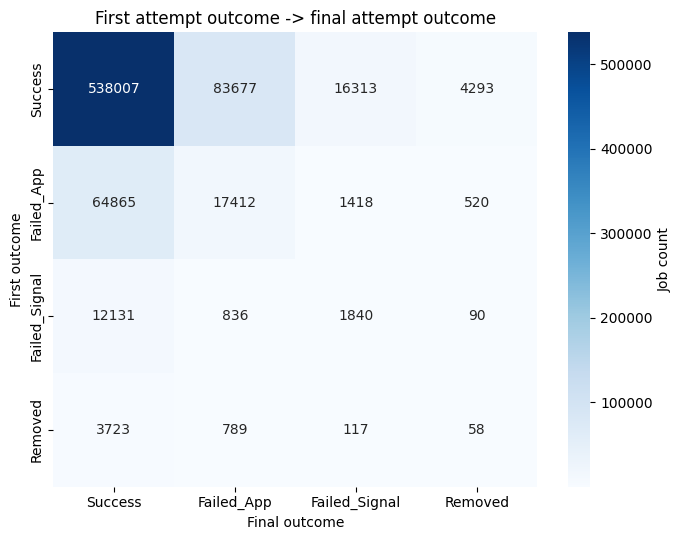

In [10]:
plt.figure(figsize=(7, 5.5))
sns.heatmap(heat, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "Job count"})
plt.title("First attempt outcome -> final attempt outcome")
plt.xlabel("Final outcome")
plt.ylabel("First outcome")
plt.tight_layout()
plt.show()


Two things stand out:

- **Retries do recover real failures**: 64,864 jobs went `Failed_App -> Success` and 12,131 went `Failed_Signal -> Success` — the recovery mechanism is working as intended for roughly 77k jobs.
- **But a comparable number regress**: 83,678 jobs that already recorded `Success` on their first row show `Failed_App` on their final row, and another 16,313 show `Failed_Signal`. That's *more* apparent regressions than genuine recoveries. This most likely reflects DAGMan/POMS re-running a node after a downstream failure elsewhere in the workflow (or a post-script validation failure) even though the node's own exit code was 0 — i.e., "first outcome" here isn't always causally *before* "final outcome" in the way a human resubmission would be. That distinction (workflow-triggered re-run vs. genuine user/system retry after failure) is exactly the ambiguity the resubmission note was worried about, and it's worth a follow-up pass at the DAG level (`DAGManJobId` + `DAGNodeName`) rather than the individual-job level before trusting this transition matrix as a causal story.


## 6. Pricing the problem: core-hours burned on superseded attempts

Whatever the retry outcome, every non-final attempt still consumed real compute. The dataset's own `CoreHours` field (already computed for us) lets us total that up directly — this is the same "wasted resource" framing `data-modeling.ipynb` used for memory/disk efficiency, applied to retries instead.


In [11]:
wasted = multi.filter(~pl.col("is_final"))
total_wasted = wasted["CoreHours"].sum()
print(f"Total core-hours burned on superseded (non-final) attempts in Jan 2024: {total_wasted:,.0f}")

by_group = (
    wasted.group_by("Group")
    .agg(pl.col("CoreHours").sum().alias("wasted_corehours"), pl.len().alias("n_wasted_attempts"))
    .sort("wasted_corehours", descending=True)
)
print(by_group.head(10))


Total core-hours burned on superseded (non-final) attempts in Jan 2024: 687,138
shape: (10, 3)
┌─────────────────────┬──────────────────┬───────────────────┐
│ Group               ┆ wasted_corehours ┆ n_wasted_attempts │
│ ---                 ┆ ---              ┆ ---               │
│ str                 ┆ f64              ┆ u32               │
╞═════════════════════╪══════════════════╪═══════════════════╡
│ group_uboone        ┆ 265133.703889    ┆ 433218            │
│ group_nova          ┆ 137496.757778    ┆ 53161             │
│ group_icarus        ┆ 89158.433889     ┆ 91588             │
│ group_gm2           ┆ 60754.833056     ┆ 25465             │
│ group_mu2e          ┆ 57879.188333     ┆ 66425             │
│ group_minerva       ┆ 32393.775556     ┆ 52461             │
│ group_dune          ┆ 14552.801111     ┆ 19264             │
│ group_opportunistic ┆ 13201.248889     ┆ 337               │
│ group_des           ┆ 4781.2425        ┆ 8416              │
│ group_des_ncsa      ┆

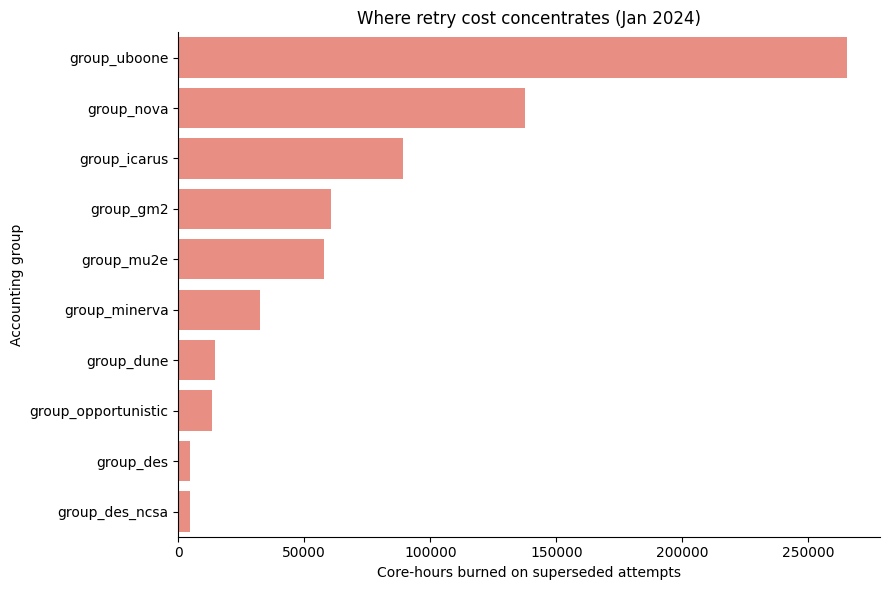

In [12]:
plot_df = by_group.head(10).to_pandas()

plt.figure(figsize=(9, 6))
sns.barplot(data=plot_df, y="Group", x="wasted_corehours", color="salmon")
plt.xlabel("Core-hours burned on superseded attempts")
plt.ylabel("Accounting group")
plt.title("Where retry cost concentrates (Jan 2024)")
sns.despine()
plt.tight_layout()
plt.show()


`group_uboone` alone accounts for roughly 40% of all core-hours lost to superseded attempts (~262k of ~661k core-hours), which lines up with it also being the group with the most multi-event jobs in absolute terms. This is the single most actionable number in this notebook for a capacity-planning conversation: it's compute that was paid for and then discarded, independent of whether the eventual retry succeeded.


## 7. What triggers the first hold, and does it predict a retry?

`fnal-jobs.ipynb` already defines regex categories for `LastHoldReason` (memory, network, filesystem, node, proxy) but only uses them as standalone binary features for the failure classifiers. Here we ask a sharper question: for jobs held on their **first** attempt, does the *reason* for that hold predict whether the job needed a second row at all?


In [11]:
job_data["LastHoldReasonCode"].unique()

LastHoldReasonCode
i64
null
3
4
6
12
16
26
33
34


In [13]:
FAILURE_PATTERNS = {
    "memory": r"memory|oom|out of memory",
    "network": r"network|connection|timeout",
    "filesystem": r"i/o|filesystem|disk",
    "node": r"slot\d+@",
    "proxy": r"x509|proxy|certificate",
}

firsts = job_data.filter(pl.col("is_first")).with_columns(
    pl.col("LastHoldReason").fill_null("NONE").str.to_lowercase().alias("hold_clean"),
    (pl.col("n_events") > 1).alias("was_retried"),
)
for name, pattern in FAILURE_PATTERNS.items():
    firsts = firsts.with_columns(pl.col("hold_clean").str.contains(pattern).alias(name))

overall_rate = firsts["was_retried"].mean()
rows = []
for name in FAILURE_PATTERNS:
    subset = firsts.filter(pl.col(name))
    n = subset.height
    if n == 0:
        continue
    rows.append({"pattern": name, "n_jobs": n, "retry_rate": subset["was_retried"].mean()})

pattern_df = pl.DataFrame(rows).sort("retry_rate", descending=True)
print(f"Baseline retry rate (all jobs): {overall_rate:.2%}")
print(pattern_df)


Baseline retry rate (all jobs): 9.48%
shape: (3, 3)
┌────────────┬────────┬────────────┐
│ pattern    ┆ n_jobs ┆ retry_rate │
│ ---        ┆ ---    ┆ ---        │
│ str        ┆ i64    ┆ f64        │
╞════════════╪════════╪════════════╡
│ memory     ┆ 138607 ┆ 0.140657   │
│ node       ┆ 204    ┆ 0.073529   │
│ filesystem ┆ 13979  ┆ 0.05401    │
└────────────┴────────┴────────────┘


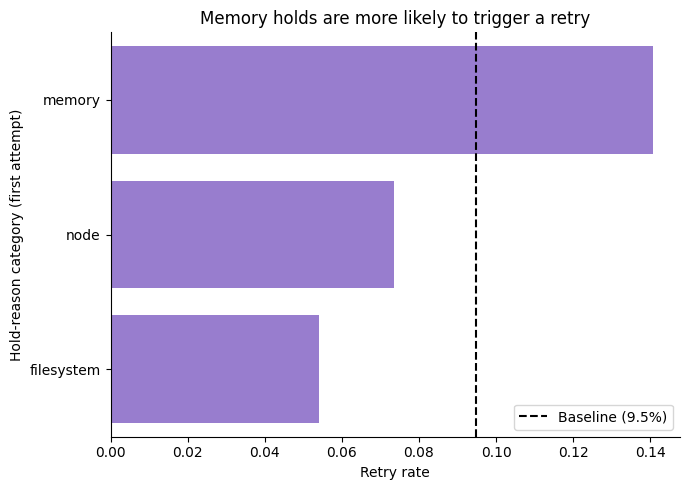

In [14]:
plot_df = pattern_df.to_pandas()

plt.figure(figsize=(7, 5))
sns.barplot(data=plot_df, y="pattern", x="retry_rate", color="mediumpurple")
plt.axvline(overall_rate, color="black", linestyle="--", label=f"Baseline ({overall_rate:.1%})")
plt.xlabel("Retry rate")
plt.ylabel("Hold-reason category (first attempt)")
plt.title("Memory holds are more likely to trigger a retry")
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()


`network` and `proxy` never appear as a first-attempt hold reason in this month's data at all (0 matches) — either those failure modes don't reach `LastHoldReason` the way the regex expects, or they genuinely don't occur upstream of a retry. Worth checking against raw `HoldReason`/`GridJobStatus` text before trusting the absence. Of the categories that do fire, `docker`/`memory` holds retry at roughly 14-15% vs. a 9.4% baseline — a real but modest signal, not a dominant driver on its own.


## 8. Who carries the retry burden: campaigns and users

Section 3 showed retries skew heavily toward DAG-managed production work. We break that down further: which accounting groups have disproportionate retry rates (not just retry volume), and — since POMS campaigns are run by individual accounts — which users are retry outliers once we control for how many jobs they submitted.


shape: (22, 3)
┌─────────────────────┬────────────┬─────────┐
│ Group               ┆ retry_rate ┆ n_jobs  │
│ ---                 ┆ ---        ┆ ---     │
│ str                 ┆ f64        ┆ u32     │
╞═════════════════════╪════════════╪═════════╡
│ group_spinquest     ┆ 0.246061   ┆ 825     │
│ group_minos         ┆ 0.219848   ┆ 4726    │
│ group_genie         ┆ 0.21132    ┆ 6696    │
│ group_uboone        ┆ 0.202524   ┆ 2100996 │
│ group_mu2e          ┆ 0.146731   ┆ 447853  │
│ group_minerva       ┆ 0.128063   ┆ 409463  │
│ group_icarus        ┆ 0.099356   ┆ 914777  │
│ group_gm2           ┆ 0.093522   ┆ 262164  │
│ group_annie         ┆ 0.039827   ┆ 31963   │
│ group_seaquest      ┆ 0.031161   ┆ 22432   │
│ …                   ┆ …          ┆ …       │
│ group_des           ┆ 0.018205   ┆ 462120  │
│ group_fermilab      ┆ 0.009119   ┆ 329     │
│ group_opportunistic ┆ 0.006551   ┆ 37855   │
│ group_des_ncsa      ┆ 0.002367   ┆ 1690    │
│ group_sbnd          ┆ 0.002087   ┆ 131777  

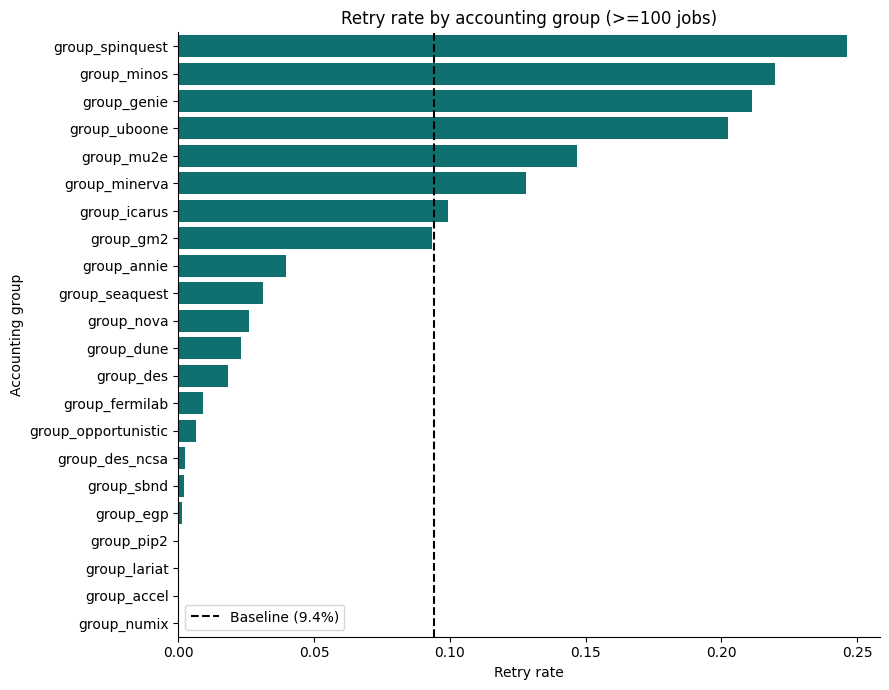

In [14]:
group_retry = (
    firsts.group_by("Group")
    .agg(pl.col("was_retried").mean().alias("retry_rate"), pl.len().alias("n_jobs"))
    .filter(pl.col("n_jobs") >= 100)
    .sort("retry_rate", descending=True)
)
print(group_retry)

plot_df = group_retry.to_pandas()
plt.figure(figsize=(9, 7))
sns.barplot(data=plot_df, y="Group", x="retry_rate", color="teal")
plt.axvline(overall_rate, color="black", linestyle="--", label=f"Baseline ({overall_rate:.1%})")
plt.xlabel("Retry rate")
plt.ylabel("Accounting group")
plt.title("Retry rate by accounting group (>=100 jobs)")
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()


In [1]:
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

# 1. Label jobs as 'Production' vs 'User' and aggregate
group_job_type_retry = (
    firsts.with_columns(
        pl.when(
            pl.col("POMS4_CAMPAIGN_NAME").is_not_null()
            & (pl.col("POMS4_CAMPAIGN_NAME") != "")
        )
        .then(pl.lit("Production"))
        .otherwise(pl.lit("User"))
        .alias("Job_Type")
    )
    .group_by(["Group", "Job_Type"])
    .agg(
        pl.col("was_retried").mean().alias("retry_rate"),
        pl.len().alias("n_jobs"),
    )
    # Filter out groups that don't have a solid sample size of jobs
    .filter(pl.col("n_jobs") >= 100)
    .filter(pl.col("retry_rate") > 0.0)
    .sort("retry_rate", descending=True)
)

print(group_job_type_retry)

# Convert to Pandas for visualization
plot_df = group_job_type_retry.to_pandas()

# 2. Plotting with Hue Separation
plt.figure(figsize=(10, 10))

sns.set_context("talk")

# Seaborn handles the two bars per group using y="Group" and hue="Job_Type"
sns.barplot(
    data=plot_df,
    y="retry_rate",
    x="Group",
    hue="Job_Type",
    palette={"Production": "teal", "User": "orange"},
)

# Reference line and formatting
plt.axvline(
    overall_rate,
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"Baseline ({overall_rate:.1%})",
)
plt.ylabel("Resubmission rate")
plt.xlabel("Accounting Group")
plt.title("Job Resubmission Rate by Group")
plt.legend(title="Job Category", loc="lower right")

sns.despine()
plt.tight_layout()
plt.show()

NameError: name 'firsts' is not defined

In [66]:
job_data.head()

GlobalJobId,ClusterId,ProcId,JobStatus,LastJobStatus,EnteredCurrentStatus_ms,QDate_ms,ExitCode,ExitSignal,LastHoldReason,LastHoldReasonCode,RemoveReason,DAGManJobId,POMS4_CAMPAIGN_STAGE_NAME,POMS4_CAMPAIGN_NAME,Group,User,RemoteWallClockTime,CoreHours,RequestCpus,RequestMemory,JOB_EXPECTED_MAX_LIFETIME,MATCH_EXP_JOB_Site,n_events,event_index,is_first,is_final,outcome
str,i64,i64,i64,i64,i64,i64,i64,i64,str,i64,str,i64,str,str,str,str,i64,f64,i64,i64,i64,str,u32,u32,bool,bool,str
"""jobsub04.fnal.gov#7288687.0#17…",7288687,0,4,2,1704644292000,1704644201000,0,null,"""Spooling input data files""",16,null,null,"""merge_mcc9_25a""","""Merge""","""group_uboone""","""uboonepro@fnal.gov""",86,0.023889,1,1000,28800,"""FermiGrid""",2,1,true,false,"""Success"""
"""jobsub03.fnal.gov#51973053.169…",51973053,1691,4,2,1705033942000,1705030803000,null,6,"""Spooling input data files""",16,null,null,null,null,"""group_nova""","""novapro@fnal.gov""",643,0.178611,1,2400,28800,"""FermiGrid""",1,1,true,true,"""Failed_Signal"""
"""jobsub05.fnal.gov#7135878.0#17…",7135878,0,4,2,1704320825000,1704302043000,0,null,null,null,null,7124768,null,null,"""group_uboone""","""cthorpe@fnal.gov""",18290,5.080556,1,4000,28800,"""FermiGrid""",2,2,false,true,"""Success"""
"""jobsub03.fnal.gov#51653599.210…",51653599,210,4,2,1704398404000,1704395259000,0,null,"""Spooling input data files""",16,null,null,null,null,"""group_nova""","""nibir@fnal.gov""",1238,0.341944,1,1900,10800,"""Michigan""",1,1,true,true,"""Success"""
"""jobsub01.fnal.gov#66777611.0#1…",66777611,0,4,2,1705162165000,1705153646000,1,null,null,null,null,66708070,"""generation""","""MDC2020_CORSIKA""","""group_mu2e""","""mu2epro@fnal.gov""",8455,2.348611,1,4000,86400,"""FermiGrid""",1,1,true,true,"""Failed_App"""


shape: (29, 6)
┌─────────────────────┬────────────┬─────────┬────────┬────────────┬──────────┐
│ Group               ┆ Job_Type   ┆ Outcome ┆ n_jobs ┆ total_jobs ┆ rate     │
│ ---                 ┆ ---        ┆ ---     ┆ ---    ┆ ---        ┆ ---      │
│ str                 ┆ str        ┆ str     ┆ u32    ┆ u32        ┆ f64      │
╞═════════════════════╪════════════╪═════════╪════════╪════════════╪══════════╡
│ group_accel         ┆ User       ┆ Failure ┆ 3037   ┆ 108296     ┆ 0.028044 │
│ group_annie         ┆ User       ┆ Failure ┆ 685    ┆ 33190      ┆ 0.020639 │
│ group_des           ┆ User       ┆ Failure ┆ 7280   ┆ 475564     ┆ 0.015308 │
│ group_des_ncsa      ┆ User       ┆ Failure ┆ 26     ┆ 2550       ┆ 0.010196 │
│ group_dune          ┆ Production ┆ Failure ┆ 3208   ┆ 24663      ┆ 0.130073 │
│ group_dune          ┆ User       ┆ Failure ┆ 85741  ┆ 776350     ┆ 0.110441 │
│ group_egp           ┆ User       ┆ Failure ┆ 2707   ┆ 138345     ┆ 0.019567 │
│ group_fermilab      ┆ U

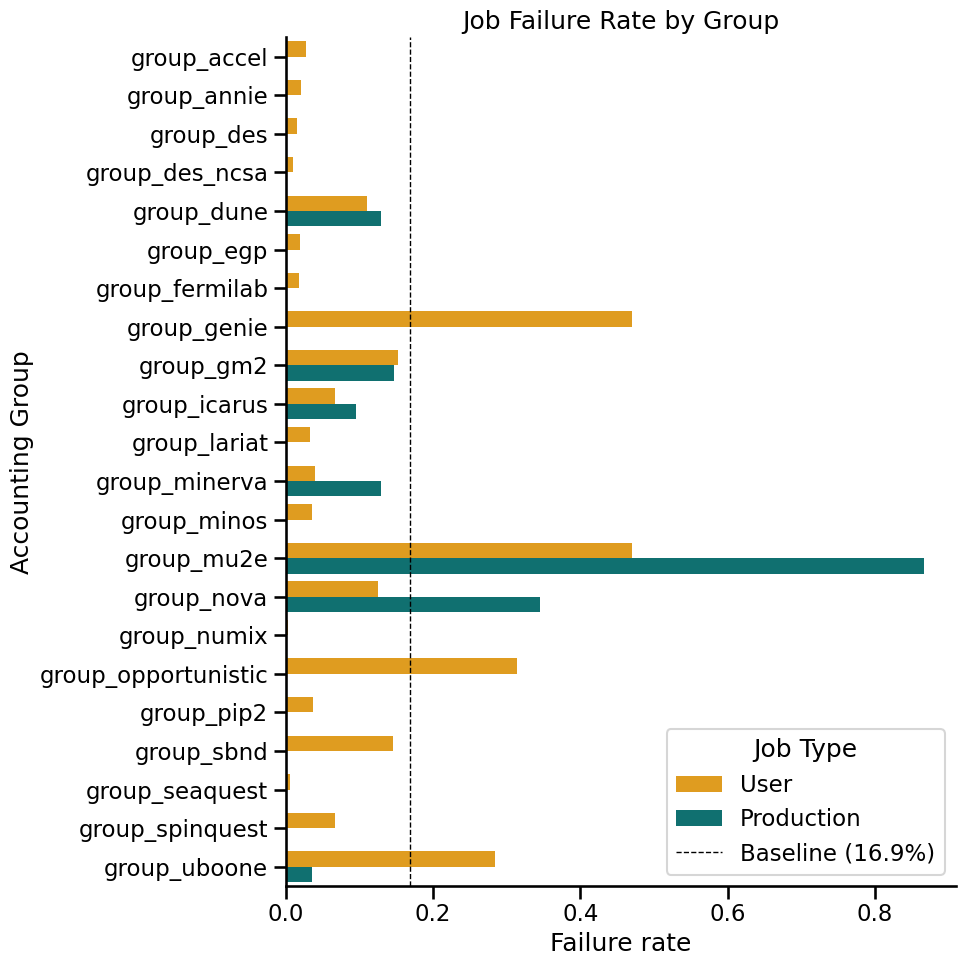

In [71]:
outcome_rates = (
    job_data.with_columns(
        pl.when(
            pl.col("POMS4_CAMPAIGN_NAME").is_not_null()
            | (pl.col("User").str.contains("pro"))
        )
        .then(pl.lit("Production"))
        .otherwise(pl.lit("User"))
        .alias("Job_Type"),
        pl.when(pl.col("outcome") == "Success")
        .then(pl.lit("Success"))
        .otherwise(pl.lit("Failure"))
        .alias("Outcome"),
    )
    .group_by(["Group", "Job_Type", "Outcome"])
    .agg(pl.len().alias("n_jobs"))
    .with_columns(
        # 1. Calculate total jobs for this Group + Job_Type combo
        pl.col("n_jobs").sum().over(["Group", "Job_Type"]).alias("total_jobs")
    )
    .with_columns(
        # 2. Calculate the rate using that total
        (pl.col("n_jobs") / pl.col("total_jobs")).alias("rate")
    )
    # 3. Filter out low volume based on TOTAL jobs, not just failures
    .filter(pl.col("total_jobs") >= 100)
    # 4. Now keep only the failure rows for the visualization
    .filter(pl.col("Outcome") == "Failure")
    .sort(["Group", "Job_Type", "Outcome"])
)

print(outcome_rates)

plot_df = outcome_rates.to_pandas()
baseline_failure_rate = (job_data.with_columns(
    pl.when(pl.col("outcome") == "Success")
    .then(pl.lit("Success"))
    .otherwise(pl.lit("Failure"))
    .alias("Outcome")
).filter(pl.col("Outcome") == "Failure").height / job_data.height)

plt.figure(figsize=(10, 10))
palette = {"Production": "teal", "User": "orange"}

sns.barplot(
    data=plot_df,
    y="Group",
    x="rate",
    hue="Job_Type",
    palette=palette,
    dodge=True,
)
plt.title("Job Failure Rate by Group")
plt.xlabel("Failure rate")
plt.ylabel("Accounting Group")
plt.axvline(baseline_failure_rate, color="black", linestyle="--", linewidth=1, label=f"Baseline ({baseline_failure_rate:.1%})")
plt.legend(title="Job Type", loc="lower right")
sns.despine()
plt.tight_layout()
plt.show()


## 9. Does this hold up across all 6 months, or is it a January artifact?

Everything above uses `processed_job_data_01.parquet` (Jan 2024) only. The `data/` directory actually has six months (Jan-Jun 2024). Before trusting group-level resubmission/failure rates as an operational signal, we rebuild the same pipeline (dedup → multi-event detection → first/final split → outcome classification) on all six files concatenated, and recreate the two group-level rate charts.

One correctness wrinkle: `ClusterId` ranges actually **overlap** across months (e.g. Jan's max ClusterId is higher than Feb's min), so `(ClusterId, ProcId)` alone is not a safe job key once multiple months are combined — two unrelated jobs from different months could collide. We key on `(month, ClusterId, ProcId)` instead. New variables are suffixed `_all` throughout so nothing above (which is Jan-only) is disturbed.


In [15]:
months = ["01", "02", "03", "04", "05", "06"]

frames = [
    pl.scan_parquet(f"../data/processed_job_data_{m}.parquet")
    .select(cols)
    .with_columns(pl.lit(m).alias("month"))
    for m in months
]
job_data_all = pl.concat(frames).collect()
print(f"Loaded {job_data_all.shape[0]:,} rows x {job_data_all.shape[1]} columns across {len(months)} months")

n_before_all = job_data_all.height
job_data_all = job_data_all.unique()
print(f"Rows after exact-duplicate removal: {job_data_all.shape[0]:,} (removed {n_before_all - job_data_all.height:,})")

job_data_all = job_data_all.with_columns(
    pl.len().over(["month", "ClusterId", "ProcId"]).alias("n_events")
)
job_data_all = job_data_all.with_columns(
    pl.col("EnteredCurrentStatus_ms").rank(method="ordinal").over(["month", "ClusterId", "ProcId"]).alias("event_index")
)
job_data_all = job_data_all.with_columns(
    (pl.col("event_index") == 1).alias("is_first"),
    (pl.col("event_index") == pl.col("n_events")).alias("is_final"),
)
job_data_all = job_data_all.with_columns(outcome_expr.alias("outcome"))

firsts_all = job_data_all.filter(pl.col("is_first")).with_columns(
    (pl.col("n_events") > 1).alias("was_retried"),
    pl.when(
        pl.col("POMS4_CAMPAIGN_NAME").is_not_null() & (pl.col("POMS4_CAMPAIGN_NAME") != "")
    ).then(pl.lit("Production")).otherwise(pl.lit("User")).alias("Job_Type"),
)

overall_rate_all = firsts_all["was_retried"].mean()

Loaded 41,079,913 rows x 24 columns across 6 months
Rows after exact-duplicate removal: 41,002,045 (removed 77,868)


In [16]:
print(f"Baseline resubmission rate across Jan-Jun 2024: {overall_rate_all:.2%}")

Baseline resubmission rate across Jan-Jun 2024: 3.92%


In [17]:
group_job_type_retry_all = (
    firsts_all.group_by(["Group", "Job_Type"])
    .agg(
        pl.col("was_retried").mean().alias("retry_rate"),
        pl.len().alias("n_jobs"),
    )
    .filter(pl.col("n_jobs") >= 100)
    .filter(pl.col("retry_rate") > 0.0)
    .sort("retry_rate", descending=True)
)
print(group_job_type_retry_all)

plot_df_sub = group_job_type_retry_all.to_pandas()


shape: (27, 4)
┌─────────────────────┬────────────┬────────────┬─────────┐
│ Group               ┆ Job_Type   ┆ retry_rate ┆ n_jobs  │
│ ---                 ┆ ---        ┆ ---        ┆ ---     │
│ str                 ┆ str        ┆ f64        ┆ u32     │
╞═════════════════════╪════════════╪════════════╪═════════╡
│ group_spinquest     ┆ User       ┆ 0.156294   ┆ 235595  │
│ group_uboone        ┆ Production ┆ 0.139553   ┆ 5929891 │
│ group_dune          ┆ Production ┆ 0.110067   ┆ 106817  │
│ group_mu2e          ┆ Production ┆ 0.076756   ┆ 854913  │
│ group_gm2           ┆ Production ┆ 0.055537   ┆ 1383661 │
│ group_seaquest      ┆ User       ┆ 0.054454   ┆ 34359   │
│ group_minerva       ┆ User       ┆ 0.052393   ┆ 1707644 │
│ group_genie         ┆ User       ┆ 0.04524    ┆ 58223   │
│ group_opportunistic ┆ User       ┆ 0.044552   ┆ 899959  │
│ group_icarus        ┆ Production ┆ 0.043216   ┆ 4213491 │
│ …                   ┆ …          ┆ …          ┆ …       │
│ group_nova          ┆ U

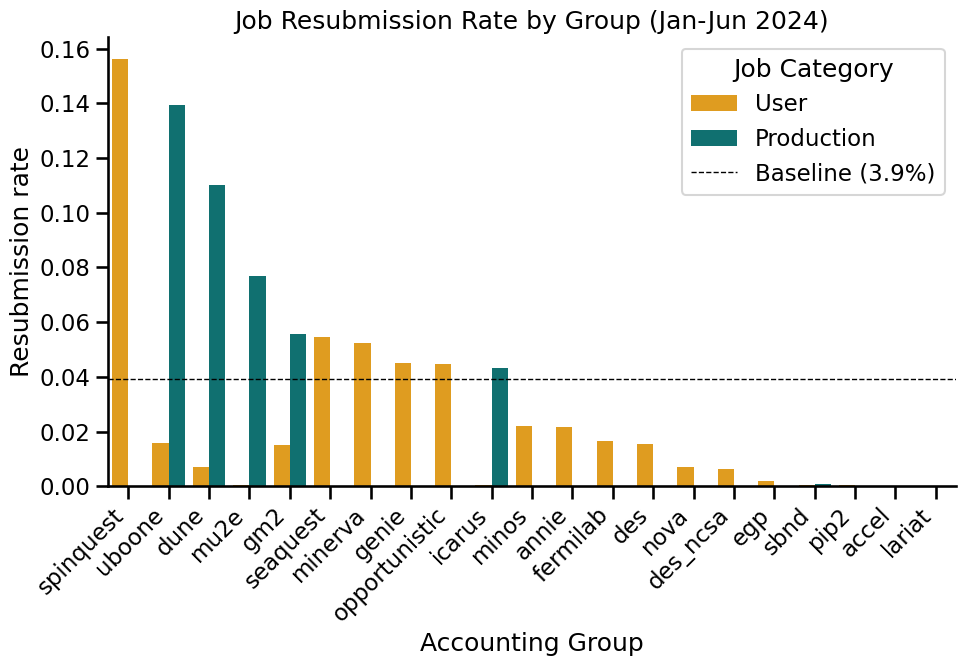

In [49]:
plt.figure(figsize=(10, 7))
sns.set_context("talk")

plot_df_sub["Group"] = plot_df_sub["Group"].str.replace("group_", "", case=False)

sns.barplot(
    data=plot_df_sub,
    y="retry_rate",
    x="Group",
    hue="Job_Type",
    palette={"Production": "teal", "User": "orange"},
)

plt.axhline(
    overall_rate_all,
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"Baseline ({overall_rate_all:.1%})",
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Resubmission rate")
plt.xlabel("Accounting Group")
plt.title("Job Resubmission Rate by Group (Jan-Jun 2024)")
plt.legend(title="Job Category", loc="upper right")

sns.despine()
plt.tight_layout()
plt.show()

In [18]:
outcome_rates_all = (
    job_data_all.with_columns(
        pl.when(
            pl.col("POMS4_CAMPAIGN_NAME").is_not_null()
            & (pl.col("POMS4_CAMPAIGN_NAME") != "")
        )
        .then(pl.lit("Production"))
        .otherwise(pl.lit("User"))
        .alias("Job_Type"),
        pl.when(pl.col("outcome") == "Success")
        .then(pl.lit("Success"))
        .otherwise(pl.lit("Failure"))
        .alias("Outcome"),
    )
    .group_by(["Group", "Job_Type", "Outcome"])
    .agg(pl.len().alias("n_jobs"))
    .with_columns(
        (pl.col("n_jobs") / pl.col("n_jobs").sum().over(["Group", "Job_Type"])).alias("rate")
    )
    .filter(pl.col("Outcome") == "Failure")
    .filter(pl.col("n_jobs") >= 100)
    .sort(["Group", "Job_Type", "Outcome"])
)

print(outcome_rates_all)

plot_df_fail = outcome_rates_all.to_pandas()
baseline_failure_rate_all = (
    job_data_all.with_columns(
        pl.when(pl.col("outcome") == "Success")
        .then(pl.lit("Success"))
        .otherwise(pl.lit("Failure"))
        .alias("Outcome")
    ).filter(pl.col("Outcome") == "Failure").height / job_data_all.height
)

shape: (27, 5)
┌─────────────────────┬────────────┬─────────┬─────────┬──────────┐
│ Group               ┆ Job_Type   ┆ Outcome ┆ n_jobs  ┆ rate     │
│ ---                 ┆ ---        ┆ ---     ┆ ---     ┆ ---      │
│ str                 ┆ str        ┆ str     ┆ u32     ┆ f64      │
╞═════════════════════╪════════════╪═════════╪═════════╪══════════╡
│ group_accel         ┆ User       ┆ Failure ┆ 13535   ┆ 0.062506 │
│ group_annie         ┆ User       ┆ Failure ┆ 11384   ┆ 0.06971  │
│ group_des           ┆ User       ┆ Failure ┆ 270652  ┆ 0.052906 │
│ group_des_ncsa      ┆ User       ┆ Failure ┆ 2872    ┆ 0.165782 │
│ group_dune          ┆ Production ┆ Failure ┆ 17524   ┆ 0.155928 │
│ group_dune          ┆ User       ┆ Failure ┆ 464786  ┆ 0.150255 │
│ group_egp           ┆ User       ┆ Failure ┆ 9778    ┆ 0.045672 │
│ group_fermilab      ┆ User       ┆ Failure ┆ 248     ┆ 0.100446 │
│ group_genie         ┆ User       ┆ Failure ┆ 19494   ┆ 0.324435 │
│ group_gm2           ┆ Productio

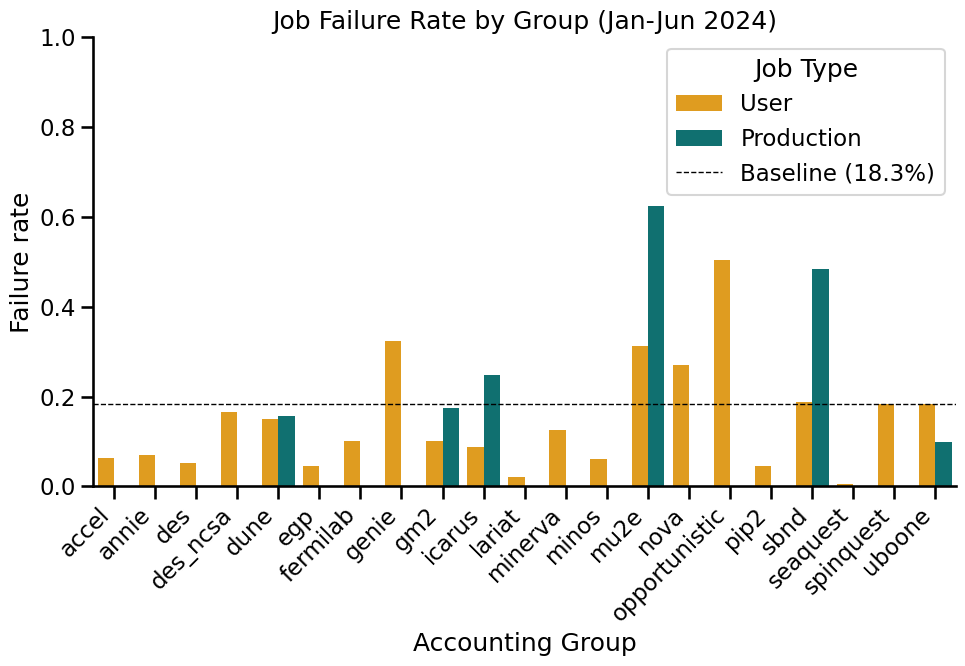

In [20]:
plt.figure(figsize=(10, 7))
sns.set_context("talk")

palette = {"Production": "teal", "User": "orange"}

plot_df_fail["Group"] = plot_df_fail["Group"].str.replace("group_", "", case=False)

sns.barplot(
    data=plot_df_fail,
    y="rate",
    x="Group",
    hue="Job_Type",
    palette=palette,
    dodge=True,
)
plt.title("Job Failure Rate by Group (Jan-Jun 2024)")
plt.ylabel("Failure rate")
plt.xlabel("Accounting Group")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.axhline(
    baseline_failure_rate_all,
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"Baseline ({baseline_failure_rate_all:.1%})",
)
plt.legend(title="Job Type", loc="upper right")
sns.despine()
plt.tight_layout()
plt.show()

January turns out to be the exception, not the rule: the baseline resubmission rate falls from 9.42% (Jan only) to 3.92% across Jan-Jun 2024 — roughly 41M rows vs. 8.6M. The *shape* of the group-level story mostly survives, though: `group_uboone` and `group_dune` Production remain the highest resubmission-rate groups by a wide margin, and `group_mu2e` Production still has by far the highest failure rate (~62% over 6 months vs. ~88% in Jan alone — still an outlier, just less extreme). `group_spinquest` User jumps to the top resubmission slot over the full window, which wasn't visible in the Jan-only chart at all — worth checking whether that's a real signal or a small-sample artifact from a campaign that only ran in a later month.


In [21]:
user_retry = (
    firsts.group_by("User")
    .agg(pl.col("was_retried").mean().alias("retry_rate"), pl.len().alias("n_jobs"))
    .filter(pl.col("n_jobs") >= 200)
)

q1 = user_retry["retry_rate"].quantile(0.25)
q3 = user_retry["retry_rate"].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

outliers = user_retry.filter(pl.col("retry_rate") > upper_fence).sort("retry_rate", descending=True)

print(f"Retry rate IQR fence (users with >=200 jobs): Q1={q1:.3f}, Q3={q3:.3f}, upper fence={upper_fence:.3f}")
print(f"{outliers.height} of {user_retry.height} qualifying users exceed the fence")
print(outliers.head(15))


Retry rate IQR fence (users with >=200 jobs): Q1=0.000, Q3=0.017, upper fence=0.041
31 of 163 qualifying users exceed the fence
shape: (15, 3)
┌─────────────────────┬────────────┬─────────┐
│ User                ┆ retry_rate ┆ n_jobs  │
│ ---                 ┆ ---        ┆ ---     │
│ str                 ┆ f64        ┆ u32     │
╞═════════════════════╪════════════╪═════════╡
│ bezawada@fnal.gov   ┆ 1.0        ┆ 202     │
│ rhatcher@fnal.gov   ┆ 0.997423   ┆ 776     │
│ chappell@fnal.gov   ┆ 0.4875     ┆ 480     │
│ linhuigu@fnal.gov   ┆ 0.321656   ┆ 1256    │
│ imawby@fnal.gov     ┆ 0.274871   ┆ 15691   │
│ pgaur@fnal.gov      ┆ 0.261905   ┆ 1008    │
│ sultana@fnal.gov    ┆ 0.257885   ┆ 539     │
│ sisrael@fnal.gov    ┆ 0.247891   ┆ 1541    │
│ ckuruppu@fnal.gov   ┆ 0.238961   ┆ 770     │
│ vansari@fnal.gov    ┆ 0.238725   ┆ 1286    │
│ rcross@fnal.gov     ┆ 0.236999   ┆ 1346    │
│ minervapro@fnal.gov ┆ 0.231598   ┆ 205580  │
│ granados@fnal.gov   ┆ 0.224427   ┆ 11135   │
│ uboonepro

A handful of accounts run at or near a 100% retry rate on hundreds-to-thousands of jobs (`uboonepro@fnal.gov` alone submitted ~1.9M jobs at a 22% retry rate — consistent with it being a POMS production/robot account, not a person making mistakes). That reinforces the section 3 finding: this is primarily a workflow-configuration signal (which campaigns/stages retry-loop) rather than a "user error" signal in the sense `data-modeling.ipynb`'s Data Groups table used for standalone `condor_submit` jobs. Any follow-up here should join back to `POMS4_CAMPAIGN_NAME`/`POMS4_CAMPAIGN_STAGE_NAME` to name the specific campaigns responsible, not the accounts.


## Summary & recommended next steps

**Findings:**
- `(ClusterId, ProcId)` is not a unique job key: 9.4% of jobs (17.2% of rows) produced two lifecycle rows in Jan 2024, on top of a separate, smaller (~0.16%) exact-duplication artifact in the ETL.
- Every multi-event job in this month has exactly two rows — no long tail of repeated retries — so a simple first/final join is sufficient for now; that should be re-checked on a longer time range before assuming it always holds.
- Multi-event jobs are DAG-linked 83% of the time vs. 36% for single-event jobs: retries are predominantly a workflow-recovery mechanism, not individual user resubmission.
- Retries recover real failures (~77k jobs went from failed to success) but a similar-or-larger number of jobs show a first-attempt success followed by a final-attempt failure — a pattern that needs DAG-level (not job-level) investigation to interpret causally.
- Superseded attempts burned ~660k core-hours in a single month, ~40% of it in one accounting group (`group_uboone`).
- Docker/memory-related first-attempt holds retry ~50% more often than baseline; network/proxy patterns never appear as a first-attempt hold reason at all in this month's data.

**Where this goes next:**
1. **Feed it back into the existing failure models.** `baseline-prediction.ipynb` and `fnal-jobs.ipynb` currently predict `Failed` from a single row's features. Collapse each job to one row (`n_events`, `first_outcome`, `first_hold_pattern`, DAG-linkage) and use only *first-attempt, pre-outcome* features to predict **"will this job need a retry"** prospectively — a genuinely new, actionable target, versus the current post-hoc failure classification.
2. **Validate against a longer time range.** This is one month; check whether the "max 2 events per job" finding and the DAG-linkage skew hold for Feb-Jun 2024 before generalizing.
3. **Push the `Success -> Failed_App` regression down to the DAG level.** Join `DAGManJobId`/`DAGNodeName` across the full graph (not just node-local retries) to see whether these are re-runs triggered by sibling-node failures, which would change how they should be labeled.
4. **Turn section 6/8 into an operator-facing report**, not just a notebook finding: core-hours-wasted by campaign stage is exactly the kind of number a capacity-planning or campaign-owner conversation needs, and it's already computable from columns that exist in this file.
